In [259]:
import pathlib


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [260]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [261]:
def load_flows(path: pathlib.Path) -> pd.DataFrame:
    flows = pd.DataFrame()
    
    for file in path.glob('*.csv'):
        flows = pd.concat([flows, pd.read_csv(file)])
    
    return flows

In [262]:
flows = load_flows(pathlib.Path('../../../datasets/cherry-picked/dapt2020-nfstream'))
flows = flows[flows['stage'] != 'Data Exfiltration']

flows['src2dst_packet_rate'] = flows['src2dst_packets'] / (flows['src2dst_duration_ms'] / 1000 + 1e-6)
flows['dst2src_packet_rate'] = flows['dst2src_packets'] / (flows['dst2src_duration_ms'] / 1000 + 1e-6)
flows['src2dst_byte_rate'] = flows['src2dst_bytes'] / (flows['src2dst_duration_ms'] / 1000 + 1e-6)
flows['dst2src_byte_rate'] = flows['dst2src_bytes'] / (flows['dst2src_duration_ms'] / 1000 + 1e-6)

flows.loc[flows['activity'] == 'Unknown', 'activity'] = 'Normal'
flows.loc[flows['stage'] == 'Unknown', 'stage'] = 'Benign'

flows.sort_values(by='bidirectional_first_seen_ms', kind='mergesort', inplace=True, ignore_index=True)

In [263]:
flows

,id,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,ip_version,vlan_id,tunnel_id,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_first_seen_ms,dst2src_last_seen_ms,dst2src_duration_ms,dst2src_packets,dst2src_bytes,bidirectional_min_ps,bidirectional_mean_ps,bidirectional_stddev_ps,bidirectional_max_ps,src2dst_min_ps,src2dst_mean_ps,src2dst_stddev_ps,src2dst_max_ps,dst2src_min_ps,dst2src_mean_ps,dst2src_stddev_ps,dst2src_max_ps,bidirectional_min_piat_ms,bidirectional_mean_piat_ms,bidirectional_stddev_piat_ms,bidirectional_max_piat_ms,src2dst_min_piat_ms,src2dst_mean_piat_ms,src2dst_stddev_piat_ms,src2dst_max_piat_ms,dst2src_min_piat_ms,dst2src_mean_piat_ms,dst2src_stddev_piat_ms,dst2src_max_piat_ms,bidirectional_syn_packets,bidirectional_cwr_packets,bidirectional_ece_packets,bidirectional_urg_packets,bidirectional_ack_packets,bidirectional_psh_packets,bidirectional_rst_packets,bidirectional_fin_packets,src2dst_syn_packets,src2dst_cwr_packets,src2dst_ece_packets,src2dst_urg_packets,src2dst_ack_packets,src2dst_psh_packets,src2dst_rst_packets,src2dst_fin_packets,dst2src_syn_packets,dst2src_cwr_packets,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,activity,stage,src2dst_packet_rate,dst2src_packet_rate,src2dst_byte_rate,dst2src_byte_rate
0,0,0,192.168.3.29,08:00:27:7d:1f:56,08:00:27,22,192.168.3.1,00:0e:0c:b4:40:5e,00:0e:0c,54587,6,4,0,0,1563223537823,1563223542144,4321,34,3380,1563223537823,1563223542144,4321,13,1642,1563223537823,1563223542144,4321,21,1738,66,99.411765,42.627433,258,66,126.307692,53.428121,258,66,82.761905,22.895206,138,0,130.939394,319.781756,1124,0,360.083333,456.994024,1125,0,216.050000,390.988555,1124,0,0,0,0,34,19,0,2,0,0,0,0,13,11,0,1,0,0,0,0,21,8,0,1,SSH,RemoteAccess,0,1,NaN,NaN,NaN,NaN,NaN,Normal,Benign,3.008562e+00,4.859985e+00,3.800045e+02,4.022216e+02
1,2,1,0.0.0.0,f8:bc:12:3a:d0:f8,f8:bc:12,68,255.255.255.255,ff:ff:ff:ff:ff:ff,ff:ff:ff,67,17,4,0,0,1563223538211,1563225336287,1798076,1334,442860,1563223538211,1563225336287,1798076,1334,442860,0,0,0,0,0,330,331.979010,2.484372,342,330,331.979010,2.484372,342,0,0.000000,0.000000,0,4,1348.894224,1094.003820,3313,4,1348.894224,1094.003820,3313,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DHCP,Network,0,6,idrac-22ptk02,"1,3,6,12,15,28,42,43",NaN,NaN,NaN,Normal,Benign,7.419041e-01,0.000000e+00,2.462966e+02,0.000000e+00
2,3,0,192.168.3.29,08:00:27:7d:1f:56,08:00:27,46299,8.8.8.8,00:0e:0c:b4:40:5e,00:0e:0c,53,17,4,0,0,1563223538979,1563223539001,22,4,441,1563223538979,1563223538986,7,2,174,1563223538993,1563223539001,8,2,267,87,110.250000,29.341381,148,87,87.000000,0.000000,87,119,133.500000,20.506097,148,7,7.333333,0.577350,8,7,7.000000,0.000000,7,8,8.000000,0.000000,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DNS.Canonical,Network,0,6,daisy.ubuntu.com,NaN,NaN,NaN,NaN,Normal,Benign,2.856735e+02,2.499688e+02,2.485359e+04,3.337083e+04
3,4,0,192.168.3.29,08:00:27:7d:1f:56,08:00:27,53331,8.8.8.8,00:0e:0c:b4:40:5e,00:0e:0c,53,17,4,0,0,1563223539006,1563223539020,14,4,441,1563223539006,1563223539006,0,2,174,1563223539020,1563223539020,0,2,267,87,110.250000,29.341381,148,87,87.000000,0.000000,87,119,133.500000,20.506097,148,0,4.666667,8.082904,14,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DNS.Canonical,Network,0,6,daisy.ubuntu.com,NaN,NaN,NaN,NaN,Normal,Benign,2.000000e+06,2.000000e+06,1.740000e+08,2.670000e+08
4,1,0,192.168.3.29,08:00:27:7d:1f:56,08:00:27,38348,8.8.8.8,00:0e:0c:b4:40:5e,00:0e:0c,53,17,4,0,0,1563223539079,1563223539101,

In [264]:
flows['stage'].value_counts()

stage
Benign                39018
Reconnaissance         6337
Establish Foothold     4438
Lateral Movement        607
Name: count, dtype: int64

In [265]:
stage_to_i = {
    'Benign': 0,
    'Reconnaissance': 1,
    'Establish Foothold': 2,
    'Lateral Movement': 3,
    # 'Data Exfiltration': 4
}

scaler = StandardScaler()

preprocessed_flows = pd.DataFrame()

for feature in ['src_port', 'dst_port', 'protocol']:
    preprocessed_flows[feature] = flows[feature].factorize()[0]

for feature in [
    'src2dst_duration_ms',
    'dst2src_duration_ms',
    'src2dst_packets',
    'dst2src_packets',
    'src2dst_packet_rate',
    'dst2src_packet_rate',
    'src2dst_byte_rate',
    'dst2src_byte_rate',
    'src2dst_mean_piat_ms',
    'dst2src_mean_piat_ms'
]:
    preprocessed_flows[feature] = np.log1p(flows[feature])
    preprocessed_flows[feature] = scaler.fit_transform(preprocessed_flows[[feature]])
    
preprocessed_flows['class'] = flows['stage'].map(stage_to_i)


In [266]:
preprocessed_flows.head(16)

,src_port,dst_port,protocol,src2dst_duration_ms,dst2src_duration_ms,src2dst_packets,dst2src_packets,src2dst_packet_rate,dst2src_packet_rate,src2dst_byte_rate,dst2src_byte_rate,src2dst_mean_piat_ms,dst2src_mean_piat_ms,class
0,0,0,0,1.314473,1.426265,0.444294,0.806666,-1.391066,-1.179260,-1.342712,-1.203836,1.435693,1.309967,0
1,1,1,1,2.830049,-0.811006,3.468546,-1.224384,-1.548433,-1.512080,-1.422769,-2.259142,1.908034,-0.700175,0
2,2,2,1,-0.266764,-0.223799,-0.577881,-0.502512,-0.584847,-0.472044,-0.568853,-0.427068,0.071092,0.120760,0
3,3,2,1,-0.789344,-0.811006,-0.577881,-0.502512,1.086216,1.218894,1.071067,1.153791,-0.673751,-0.700175,0
4,4,2,1,-0.266764,-0.223799,-0.577881,-0.502512,-0.584847,-0.472044,-0.568853,-0.427068,0.071092,0.120760,0
5,5,2,1,-0.789344,-0.811006,-0.577881,-0.502512,1.086216,1.218894,1.071067,1.153791,-0.673751,-0.700175,0
6,6,3,0,2.830077,3.038011,3.266121,3.229045,-1.570883,-1.437310,-1.203102,-1.416125,2.017467,2.149624,0
7,7,2,1,-0.440957,-0.440519,-0.577881,-0.502512,-0.425278,-0.287930,-0.411954,-0.254580,-0.177189,-0.182223,0
8,8,2,1,-0.789344,-0.811006,-0.577881,-0.502512,1.086216,1.218894,1.087361,1.274393,-0.673751,-0.700175,0
9,9,4,0,2.284375,2.457669,0.992843,0.916433,-1.626635,-1.490421,-1.906068,-1.746727,2.489044,2.682188,0


In [ ]:
random_seed = 42
batch_size = 128

sequence_length = 16

num_src_ports = preprocessed_flows['src_port'].nunique()
num_dst_ports = preprocessed_flows['dst_port'].nunique()
num_protocols = preprocessed_flows['protocol'].nunique()

num_classes = len(stage_to_i)


In [268]:
sequences = []
classes = []

for i in range(0, len(preprocessed_flows) - sequence_length + 1, sequence_length):
    sequence = preprocessed_flows.iloc[i:i+sequence_length]
    
    sequences.append(preprocessed_flows.iloc[i:i+sequence_length])
    classes.append(sequence['class'].max())

train_indices, val_indices = train_test_split(np.arange(len(sequences)), test_size=0.1, random_state=random_seed, stratify=classes)
train_indices.sort()
val_indices.sort()

train_flows = pd.concat([sequences[i] for i in train_indices], ignore_index=True)
val_flows = pd.concat([sequences[i] for i in val_indices], ignore_index=True)

In [269]:
train_flows.head(16)

,src_port,dst_port,protocol,src2dst_duration_ms,dst2src_duration_ms,src2dst_packets,dst2src_packets,src2dst_packet_rate,dst2src_packet_rate,src2dst_byte_rate,dst2src_byte_rate,src2dst_mean_piat_ms,dst2src_mean_piat_ms,class
0,0,0,0,1.314473,1.426265,0.444294,0.806666,-1.391066,-1.179260,-1.342712,-1.203836,1.435693,1.309967,0
1,1,1,1,2.830049,-0.811006,3.468546,-1.224384,-1.548433,-1.512080,-1.422769,-2.259142,1.908034,-0.700175,0
2,2,2,1,-0.266764,-0.223799,-0.577881,-0.502512,-0.584847,-0.472044,-0.568853,-0.427068,0.071092,0.120760,0
3,3,2,1,-0.789344,-0.811006,-0.577881,-0.502512,1.086216,1.218894,1.071067,1.153791,-0.673751,-0.700175,0
4,4,2,1,-0.266764,-0.223799,-0.577881,-0.502512,-0.584847,-0.472044,-0.568853,-0.427068,0.071092,0.120760,0
5,5,2,1,-0.789344,-0.811006,-0.577881,-0.502512,1.086216,1.218894,1.071067,1.153791,-0.673751,-0.700175,0
6,6,3,0,2.830077,3.038011,3.266121,3.229045,-1.570883,-1.437310,-1.203102,-1.416125,2.017467,2.149624,0
7,7,2,1,-0.440957,-0.440519,-0.577881,-0.502512,-0.425278,-0.287930,-0.411954,-0.254580,-0.177189,-0.182223,0
8,8,2,1,-0.789344,-0.811006,-0.577881,-0.502512,1.086216,1.218894,1.087361,1.274393,-0.673751,-0.700175,0
9,9,4,0,2.284375,2.457669,0.992843,0.916433,-1.626635,-1.490421,-1.906068,-1.746727,2.489044,2.682188,0


In [270]:
preprocessed_flows.info()

<class 'pandas.DataFrame'>
RangeIndex: 50400 entries, 0 to 50399
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   src_port              50400 non-null  int64  
 1   dst_port              50400 non-null  int64  
 2   protocol              50400 non-null  int64  
 3   src2dst_duration_ms   50400 non-null  float64
 4   dst2src_duration_ms   50400 non-null  float64
 5   src2dst_packets       50400 non-null  float64
 6   dst2src_packets       50400 non-null  float64
 7   src2dst_packet_rate   50400 non-null  float64
 8   dst2src_packet_rate   50400 non-null  float64
 9   src2dst_byte_rate     50400 non-null  float64
 10  dst2src_byte_rate     50400 non-null  float64
 11  src2dst_mean_piat_ms  50400 non-null  float64
 12  dst2src_mean_piat_ms  50400 non-null  float64
 13  class                 50400 non-null  int64  
dtypes: float64(10), int64(4)
memory usage: 5.4 MB


In [271]:
class FlowDataset(Dataset):
    def __init__(self, flows: pd.DataFrame, sequence_length: int, sequence_stride: int):
        self.sequence_length = sequence_length
        self.sequence_stride = sequence_stride
        
        self.feature_tensors = {}

        for feature in flows.columns:
            if feature == 'class':
                continue
            
            if flows.dtypes[feature] == 'int64':
                self.feature_tensors[feature] = torch.tensor(flows[feature].values, dtype=torch.long)
            
            if flows.dtypes[feature] == 'float64':
                self.feature_tensors[feature] = torch.tensor(flows[feature].values, dtype=torch.float)
       
        self.cls_tensors = torch.tensor(flows['class'].values)

    def __len__(self) -> int:
        if len(self.cls_tensors) < self.sequence_length:
            return 0
        
        return (len(self.cls_tensors) - self.sequence_length) // self.sequence_stride + 1

    def __getitem__(self, idx) -> tuple[dict[str, torch.Tensor], torch.Tensor]:
        start_idx = idx * self.sequence_stride
        end_idx = start_idx + self.sequence_length
        
        features = {feature: tensor[start_idx:end_idx] for feature, tensor in self.feature_tensors.items()}
        cls = self.cls_tensors[start_idx:end_idx].max()
        
        return features, cls

In [272]:
train_ds = FlowDataset(train_flows, sequence_length=sequence_length, sequence_stride=1)
val_ds = FlowDataset(val_flows, sequence_length=sequence_length, sequence_stride=sequence_length)

In [273]:
train_classes  = [train_ds[i][1] for i in range(len(train_ds))]

train_class_counts = np.bincount(train_classes)
train_class_weights = 1. / train_class_counts   
train_sample_weights = train_class_weights[train_classes]

train_sampler = WeightedRandomSampler(train_sample_weights, num_samples=len(train_sample_weights), replacement=False) 
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

In [274]:
len(train_loader) * 64

22656

In [275]:

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.src_port_embedding = nn.Embedding(num_src_ports, 4)
        self.dst_port_embedding = nn.Embedding(num_dst_ports, 4)
        
        self.protocol_embedding = nn.Embedding(num_protocols, 2)
        
        self.linear_1 = nn.Linear(sequence_length * 18, 32)
        self.relu_1 = nn.LeakyReLU()
        
        self.linear_2 = nn.Linear(32, 32)
        self.relu_2 = nn.LeakyReLU()
        
        self.head = nn.Linear(32, num_classes)
        
    def forward(self, features):
        src_embed = self.src_port_embedding(features['src_port'])
        dst_embed = self.dst_port_embedding(features['dst_port'])
        proto_embed = self.protocol_embedding(features['protocol'])
        
        variables = torch.stack([
            features['src2dst_duration_ms'],
            features['dst2src_duration_ms'],
            # features['src2dst_packets'],
            # features['dst2src_packets'],
            features['src2dst_packet_rate'],
            features['dst2src_packet_rate'],
            features['src2dst_byte_rate'],
            features['dst2src_byte_rate'],
            features['src2dst_mean_piat_ms'],
            features['dst2src_mean_piat_ms'],
        ], dim=-1)
        
        x = torch.cat([src_embed, dst_embed, proto_embed, variables], dim=-1)
        x = x.view(x.size(0), -1)
        
        x = self.linear_1(x)
        x = self.relu_1(x)
        
        x = self.linear_2(x)
        x = self.relu_2(x)
        
        return x

In [276]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [277]:
model = Net()
model = model.to(device)

In [278]:
model

Net(
  (src_port_embedding): Embedding(21193, 4)
  (dst_port_embedding): Embedding(1711, 4)
  (protocol_embedding): Embedding(3, 2)
  (linear_1): Linear(in_features=72, out_features=32, bias=True)
  (relu_1): LeakyReLU(negative_slope=0.01)
  (linear_2): Linear(in_features=32, out_features=32, bias=True)
  (relu_2): LeakyReLU(negative_slope=0.01)
  (head): Linear(in_features=32, out_features=4, bias=True)
)

In [279]:
sum(p.numel() for p in model.parameters())

95146

In [280]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20


In [281]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for features, cls in loader:
        # Move data to device
        features = {k: v.to(device) for k, v in features.items()}
        cls = cls.to(device)
        
        # Forward pass
        output = model(features)
        loss = criterion(output, cls)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = output.max(1)
        correct += predicted.eq(cls).sum().item()
        total += cls.size(0)
    
    return total_loss / len(loader), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_pred = []
    all_true = []
    
    with torch.no_grad():
        for features, cls in loader:
            # Move data to device
            features = {k: v.to(device) for k, v in features.items()}
            cls = cls.to(device)
            
            # Forward pass
            output = model(features)
            loss = criterion(output, cls)
            
            # Statistics
            total_loss += loss.item()
            _, predicted = output.max(1)
            correct += predicted.eq(cls).sum().item()
            total += cls.size(0)
            
            all_pred.extend(predicted.cpu().numpy())
            all_true.extend(cls.cpu().numpy())
    
    return total_loss / len(loader), correct / total, all_pred, all_true


In [282]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print(f"Training completed!")


Epoch 5/20 - Train Loss: 0.1715, Train Acc: 0.9484, Val Loss: 0.5655, Val Acc: 0.8373
Epoch 10/20 - Train Loss: 0.1225, Train Acc: 0.9601, Val Loss: 0.5335, Val Acc: 0.8579
Epoch 15/20 - Train Loss: 0.0751, Train Acc: 0.9746, Val Loss: 0.5580, Val Acc: 0.8746
Epoch 20/20 - Train Loss: 0.0435, Train Acc: 0.9852, Val Loss: 0.5650, Val Acc: 0.8881
Training completed!


In [283]:
_, val_acc, val_predictions, val_true = validate(model, val_loader, criterion, device)

print(f"Final Validation Accuracy: {val_acc:.4f}\n")
print("Classification Report:")
print(classification_report(val_true, val_predictions, target_names=list(stage_to_i.keys())))

print("\nConfusion Matrix:")
cm = confusion_matrix(val_true, val_predictions)
print(cm)


Final Validation Accuracy: 0.8881

Classification Report:
                    precision    recall  f1-score   support

            Benign       0.88      0.99      0.93       939
    Reconnaissance       0.90      0.41      0.56       169
Establish Foothold       0.96      0.86      0.91       118
  Lateral Movement       0.95      0.56      0.70        34

          accuracy                           0.89      1260
         macro avg       0.92      0.70      0.78      1260
      weighted avg       0.89      0.89      0.87      1260


Confusion Matrix:
[[930   5   3   1]
 [ 99  69   1   0]
 [ 15   2 101   0]
 [ 14   1   0  19]]


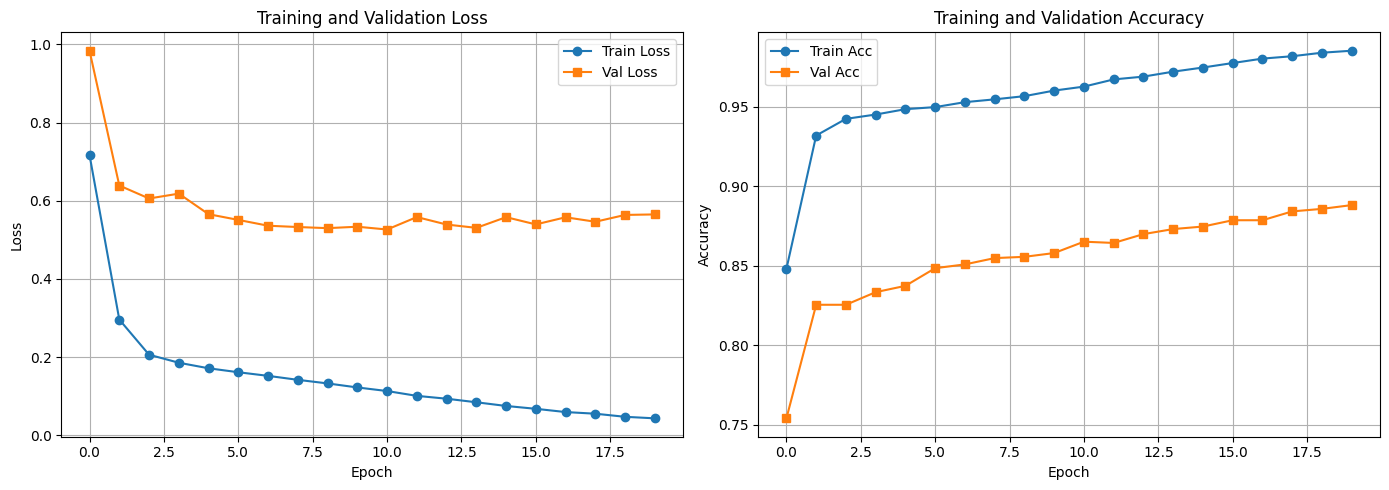

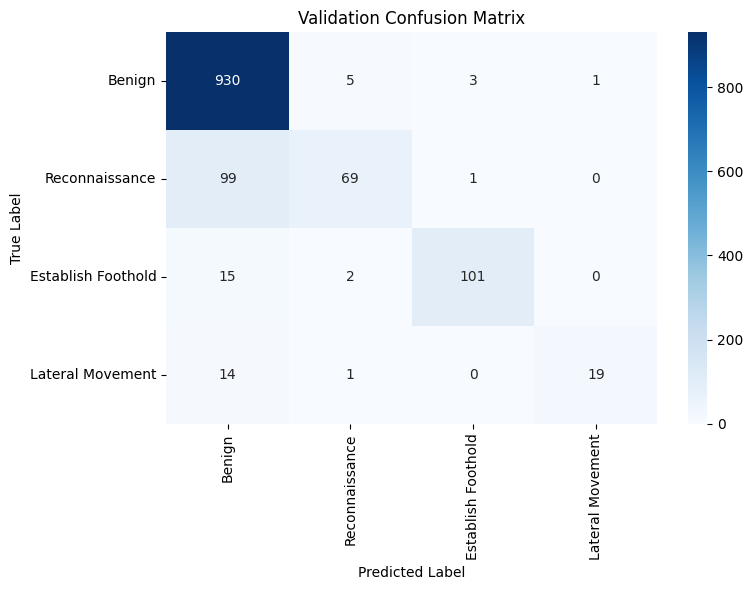

In [284]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training history
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(stage_to_i.keys()), 
            yticklabels=list(stage_to_i.keys()))
plt.title('Validation Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
